<a href="https://colab.research.google.com/github/vugaer/ml-models/blob/main/ML_Ders_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***This notebook contains additional stuff which may confuse you at first. Research might help you on that side which you can refer to [Documentations](https://scikit-learn.org/stable/api/sklearn.html) available on the internet.***

# Libraries

In [166]:
# General libraries imported!

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Linear Regression

In [167]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()  # load dataset
X1 = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)  # format as DataFrame
y1 = diabetes.target
X1.head(5)  # show first 5 rows

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


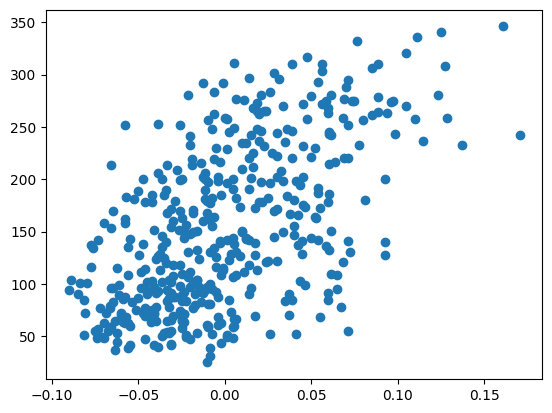

In [168]:
plt.scatter(X1.bmi, y1)  # plot the column in scatter ['bmi'] versus y

In [169]:
x1 = X1[['bmi']]
model1 = LinearRegression()
model1.fit(x1, y1)  # fit our model LinearReg()

LinearRegression()

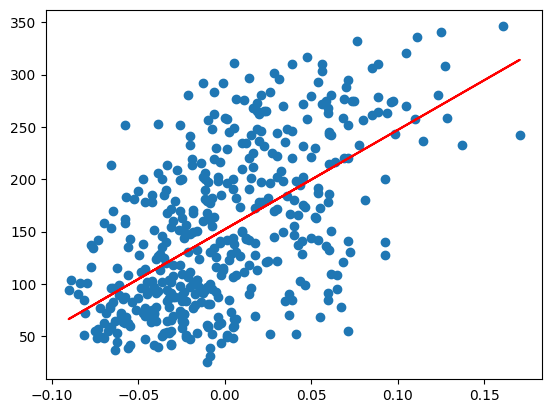

In [170]:
plt.scatter(x1, y1)
plt.plot(x1, model1.predict(x1), color='red')

# KNN

In [171]:
from sklearn.datasets import load_digits  # dataset
from sklearn.neighbors import KNeighborsClassifier  # KNN

In [172]:
digits = load_digits()
X2 = digits.data
y2 = digits.target

In [173]:
model2 = KNeighborsClassifier(n_neighbors=3)
model2.fit(X2, y2)

KNeighborsClassifier(n_neighbors=3)

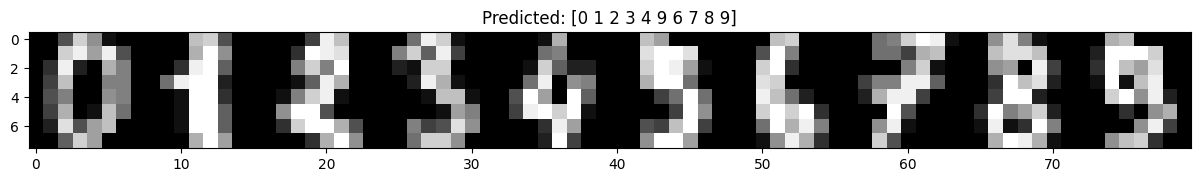

In [174]:
test_images = X2[:10].reshape(-1, 8, 8)  # test last 10 image and reshape into 8x8 pixels
guesses = model2.predict(X2[:10])
pred_img = np.hstack(test_images)
plt.figure(figsize=(15, 3))
plt.imshow(pred_img, cmap='gray')
plt.title(f'Predicted: {guesses}')
plt.show()

## Let's implement it on the function!

In [175]:
# This one is additional

def predict_digit(X, y, model, start=0, stop=10, res_w=8, res_h=8, figsize=(15, 3)):
  test_images = X[start:stop].reshape(-1, res_w, res_h)
  model.fit(X, y)
  guesses = model.predict(X[start:stop])
  pred_img = np.hstack(test_images)
  plt.figure(figsize=figsize)
  plt.imshow(pred_img, cmap='gray')
  plt.title(f'Predicted: {guesses}')
  plt.axis('off')  # to disable X and Y axis on the plot
  plt.show()
  return guesses

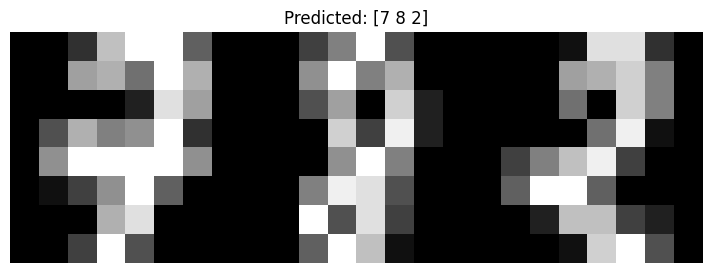

array([7, 8, 2])

In [176]:
predict_digit(X2, y2, KNeighborsClassifier(n_neighbors=3), 52, 55)

# Decision Tree

In [177]:
from sklearn.tree import DecisionTreeClassifier

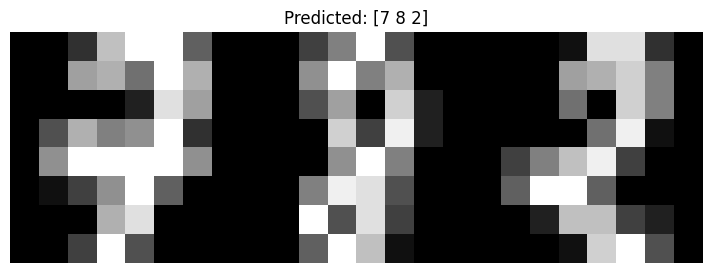

array([7, 8, 2])

In [178]:
predict_digit(X2, y2, DecisionTreeClassifier(max_depth=10), 52, 55)

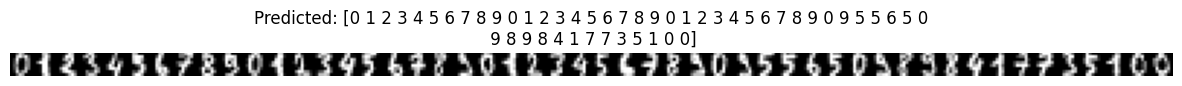

In [179]:
# Decision Tree
decision_tree = predict_digit(X2, y2, DecisionTreeClassifier(max_depth=10), 0, 50)

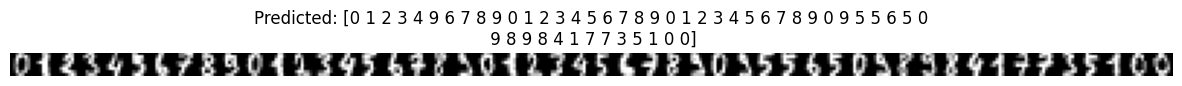

In [180]:
# KNN
knn = predict_digit(X2, y2, KNeighborsClassifier(n_neighbors=3), 0, 50)

In [181]:
knn == decision_tree

# Decision Tree got correctly, thinking it was 5 while KNN suggests it is 9 which is not correct.

array([ True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

# Iris dataset & Random Forest

In [182]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

In [183]:
iris = load_iris()
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [184]:
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [185]:
print(iris.target_names)
y
# 0 means setosa, 1 versicolor, 2 virginica.

['setosa' 'versicolor' 'virginica']


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [186]:
from sklearn.model_selection import train_test_split  # let's split it into 70% train and 30% test split!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [187]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

In [188]:
y_pred = model.predict(X_test)
y_pred  # prediction results of the test split (30%)

array([2, 0, 2, 0, 1, 1, 0, 2, 2, 1, 2, 1, 1, 1, 1, 0, 1, 2, 2, 0, 1, 2,
       0, 0, 1, 2, 0, 1, 1, 2, 1, 2, 0, 0, 0, 1, 2, 1, 0, 1, 1, 0, 1, 2,
       0])

In [191]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
# that shows how

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      0.94      0.94        18
           2       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45

